# Proyecto de mapeo de clientes

### Importar los paquetes

In [1]:
# Importar los paquetes
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd



### Levantar las fuentes del mapa

- https://gadm.org/
- https://gadm.org/download_country.html Load the GeoJSON file (Level 1 - regions) 

In [ ]:
# Sacar la fuente de donde salen los mapas

# https://gadm.org/
# https://gadm.org/download_country.html
# Load the GeoJSON file (Level 1 - regions) 
geojson_path = 'C:\\Users\\JuanCarlosSaraviaDra\\Downloads\\gadm41_PER_1.json\\gadm41_PER_1.json'
peru_regions = gpd.read_file(geojson_path) # Esto es un dataframe

peru_regions = peru_regions.reset_index() # crear una columna con el index que servirá para juntar las provincias


### Esta es la data de marketing para la geolocation

In [ ]:
# Data de marketing geolocation

source_marketing = 'C:\\Users\\JuanCarlosSaraviaDra\\Downloads\\marketing_geolocation.csv'

data_marketing = pd.read_csv(source_marketing)


### Generar un filtro que selecciona a todas las personas que son clientes

In [ ]:
# Filtrar todas las personas que son clientes
data_marketing_clients = data_marketing.loc[data_marketing['user_id'].notna()]


### Filtrar a todas las personas que no son clientes

In [ ]:
## No son clientes
data_marketing_none_clients = data_marketing.loc[~data_marketing['user_id'].notna()]

### Agregar la data de los clientes para revisar en qué regiones están

- Aquí como los nombres de las regiones eran diferentes pero en el mismo orden utilicé el indez como primary key para no estar cambiando los nombres

In [ ]:
# Agregar la data de los clientes 

data_marketing_clients = data_marketing_clients.loc[data_marketing_clients['country'] == "Peru"]

data_marketing_clients_region_Peru = data_marketing_clients.groupby(['region']).agg(
    Clientes = ('region', 'count')).reset_index()

data_marketing_clients_region_Peru = data_marketing_clients_region_Peru.reset_index()


### Agregar la data de los no clientes para ver a qué regiones pertenecen

- Aquí como los nombres de las regiones eran diferentes pero en el mismo orden utilicé el indez como primary key para no estar cambiando los nombres

In [34]:
### Agregar la data de los no clientes

data_marketing_none_clients = data_marketing_none_clients.loc[data_marketing_none_clients['country'] == "Peru"]

data_marketing_none_clients_region_Peru = data_marketing_none_clients.groupby(['region']).agg(
    Clientes = ('region', 'count')).reset_index()

data_marketing_none_clients_region_Peru = data_marketing_none_clients_region_Peru.reset_index()


### Juntar los data frames de los clientes

In [ ]:
# Merge tables
data_final = pd.merge(peru_regions, data_marketing_clients_region_Peru, how='inner', left_on= 'index', right_on='index').reset_index()

data_final.head()

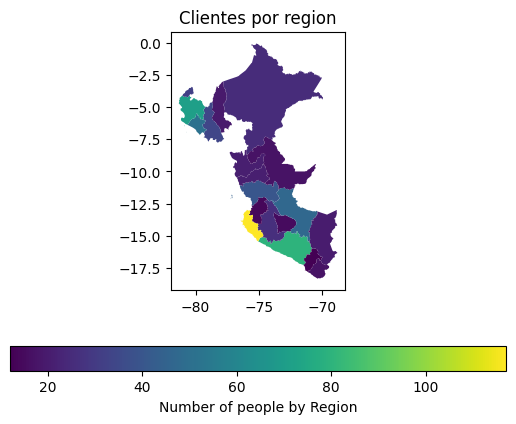

In [21]:










# Plot the data, with color intensity based on the number of cases
data_final.plot(column='Equipos', cmap='viridis', legend=True,
            legend_kwds={'label': "Number of people by Region",
                         'orientation': "horizontal"})

plt.title('Clientes por region')
plt.show()